In [1]:
# 1. 파이썬 코드에서 Matplotlib 폰트 설정
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np
from datetime import timedelta
from itertools import combinations
from collections import Counter

# 폰트 설정
plt.rc('font', family='Malgun Gothic')
# 마이너스 부호 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

print("한글 폰트 설정이 완료되었습니다.")

# 3. 데이터 로드 및 통합 (모든 문제 풀이의 시작점)
try:
    orders_df = pd.read_csv('../data/orders.csv')
    payments_df = pd.read_csv('../data/payments.csv')
    products_df = pd.read_csv('../data/products.csv')
    shipping_df = pd.read_csv('../data/shipping.csv')
    customers_df = pd.read_csv('../data/customers.csv')

    # 모든 데이터프레임 병합
    df = pd.merge(orders_df, payments_df, on='order_id', how='left')
    df = pd.merge(df, products_df, on='product_id', how='left')
    df = pd.merge(df, customers_df, on='customer_id', how='left')
    df = pd.merge(df, shipping_df, on='order_id', how='left')

    # 데이터 전처리
    date_cols = ['order_date', 'payment_date', 'join_date', 'shipping_start_date', 'shipping_end_date']
    for col in date_cols:
        df[col] = pd.to_datetime(df[col], errors='coerce') # pandas의 to_datetime 검색해서 사용법 잘 봐 두고
    df['total_sales'] = df['quantity'] * df['price']
    
    print("데이터 로드 및 통합이 완료되었습니다.")

except FileNotFoundError as e:
    print(f"파일을 찾을 수 없습니다: {e}")


한글 폰트 설정이 완료되었습니다.
데이터 로드 및 통합이 완료되었습니다.


In [ ]:
# 문제 2: 고객의 생애 가치(LTV)를 간단하게 계산하여 상위 10명의 고객을 찾으세요.
# 비즈니스 목적: 장기적으로 회사에 가장 큰 가치를 제공하는 핵심 고객을 식별하고, 이들에게 차별화된 혜택을 제공하여 관계를 유지합니다.
# 누적 구매액(LTV)

###### 출력 결과를 보고 코딩하세요
```
총 누적 구매액 기준 상위 10명 고객 (LTV):
customer_id
C0625    2894100
C1698    2761800
C1147    2756300
C1448    2463200
C1935    2422100
C0409    2245800
C1945    2227800
C0338    2221300
C1990    2207500
C0007    2200800
Name: total_sales, dtype: int64
```
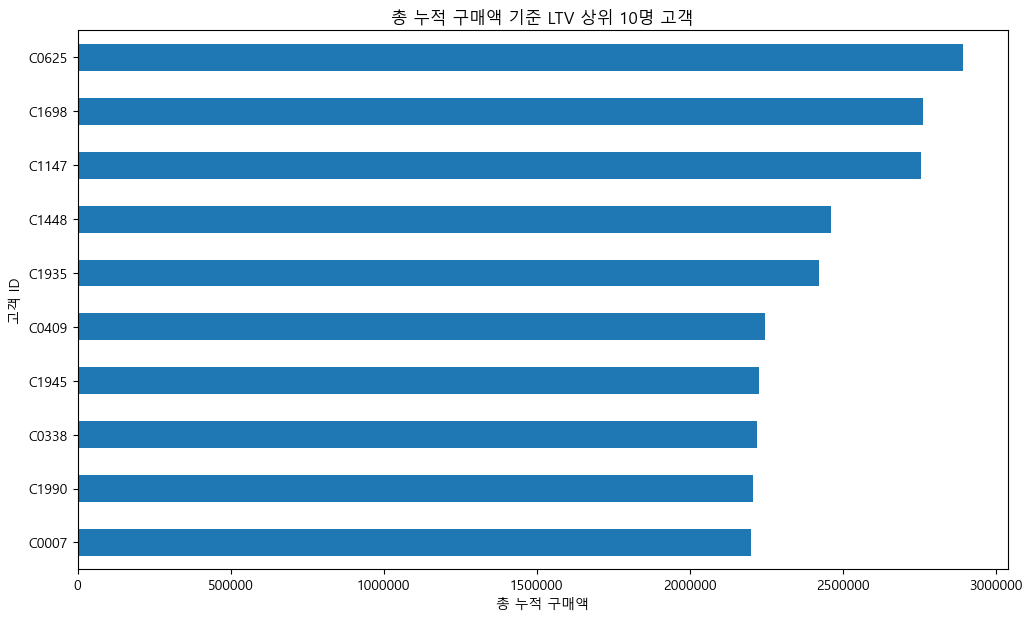

In [ ]:
df.columns

Index(['order_id', 'customer_id', 'product_id', 'order_date', 'quantity',
       'payment_id', 'payment_method', 'payment_status', 'payment_date',
       'product_name', 'category', 'price', 'stock', 'name', 'gender', 'age',
       'join_date', 'city', 'shipping_id', 'shipping_company',
       'shipping_status', 'shipping_start_date', 'shipping_end_date',
       'total_sales'],
      dtype='object')

In [ ]:
# 필요한 데이터 고객아이디로 그룹핑한 다음 총구매액을 sum()하고 sort_values()로 내립차순한 후 10명만 가져오기
customer_ltv_top10 = (
  df.groupby('customer_id')['total_sales'] # 고객아이디로 그룹핑해서 total_sales만 가져오고
  .sum()  # 그걸 누적하고
  .sort_values(ascending=False) # 내림차순으로 정렬한 다음
  .head(10) # 10개만 가져오기
)
print('총 누적 구매액 기준 상위 10명 고객 (LTV):')
customer_ltv_top10



총 누적 구매액 기준 상위 10명 고객 (LTV):


customer_id
C0625    2894100
C1698    2761800
C1147    2756300
C1448    2463200
C1935    2422100
C0409    2245800
C1945    2227800
C0338    2221300
C1990    2207500
C0007    2200800
Name: total_sales, dtype: int64

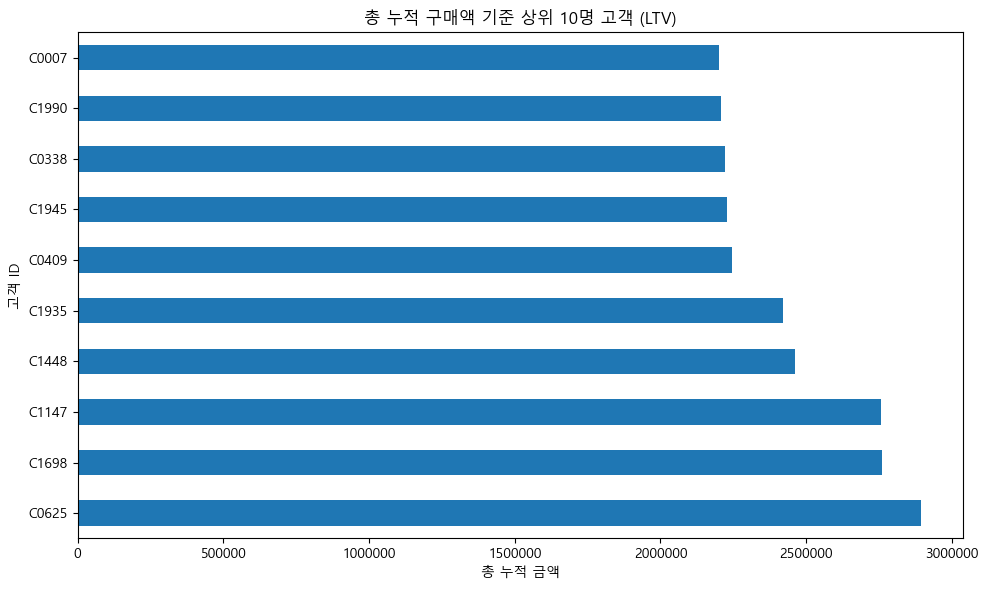

In [ ]:
# 그래프 그리기
# customer_ltv_top10.plot( 
customer_ltv_top10.sort_values().plot( # 다시 오름차순으로 해줘야 제일 위에게 큰 금액 나옴
    figsize=(10, 6), # 그래프 사이즈
    kind='barh',     # 가로 막대 그래프
    title='총 누적 구매액 기준 상위 10명 고객 (LTV)',
    xlabel='총 누적 금액',
    ylabel='고객 ID'
).ticklabel_format(style='plain', axis='x') # 이거 안해주면 0.5 ~ 이렇게 나옴

plt.tight_layout()
plt.show()